In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from utils.helpers import load_dataset, add_load_features

This notebook was used to establish the baseline workflow of training an XGBoost model on power load data.

# Load data

In [3]:
project_root = Path.cwd().parent.parent.parent

path = project_root / f"data/time_series_60.csv"
df = load_dataset(path)

df.head()

,AT_load_actual_entsoe_transparency,BE_load_actual_entsoe_transparency,BG_load_actual_entsoe_transparency,CH_load_actual_entsoe_transparency,CY_load_actual_entsoe_transparency,CZ_load_actual_entsoe_transparency,DE_load_actual_entsoe_transparency,DK_load_actual_entsoe_transparency,EE_load_actual_entsoe_transparency,ES_load_actual_entsoe_transparency,...,NL_load_actual_entsoe_transparency,NO_load_actual_entsoe_transparency,PL_load_actual_entsoe_transparency,PT_load_actual_entsoe_transparency,RO_load_actual_entsoe_transparency,RS_load_actual_entsoe_transparency,SE_load_actual_entsoe_transparency,SI_load_actual_entsoe_transparency,SK_load_actual_entsoe_transparency,UA_load_actual_entsoe_transparency
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,5946.0,9484.0,NaN,NaN,NaN,NaN,41151.0,NaN,NaN,NaN,...,9401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+00:00,5726.0,9152.0,4585.0,7640.14,NaN,5957.57,40135.0,3100.02,764.7,22734.0,...,8957.0,15104.99,13979.46,5123.9,NaN,NaN,14485.0,1045.47,2728.0,NaN
2015-01-01 02:00:00+00:00,5347.0,8799.0,4440.0,7391.44,NaN,5878.87,39106.0,2980.39,749.8,21286.0,...,8462.0,14882.56,13453.78,4771.1,NaN,NaN,14298.0,1004.79,2626.0,NaN
2015-01-01 03:00:00+00:00,5249.0,8567.0,4418.0,7332.57,NaN,5827.80,38765.0,2933.49,746.5,20264.0,...,8156.0,14755.09,13306.00,4443.5,NaN,NaN,14249.0,983.79,2618.0,NaN


# Extract only DE load

In [4]:
TARGET = 'DE_load_actual_entsoe_transparency'
df = df[[TARGET]]

# Feature engineering

In [5]:
df = add_load_features(df, TARGET, interval=60, type="nowcast")

# Remove NaN targets

In [6]:
mask_valid_target = df[TARGET].notna() # Extract rows where target is valid (not null)
df = df[mask_valid_target].copy() # Take into DataFrame only rows with valid target

# Convert data to numpy ndarrays

In [7]:
X = df.drop(TARGET, axis=1).to_numpy()
y = df[TARGET].to_numpy()

print(f'X: {X.shape}, y: {y.shape}')

X: (50400, 26), y: (50400,)


# Plotting time series train test splits

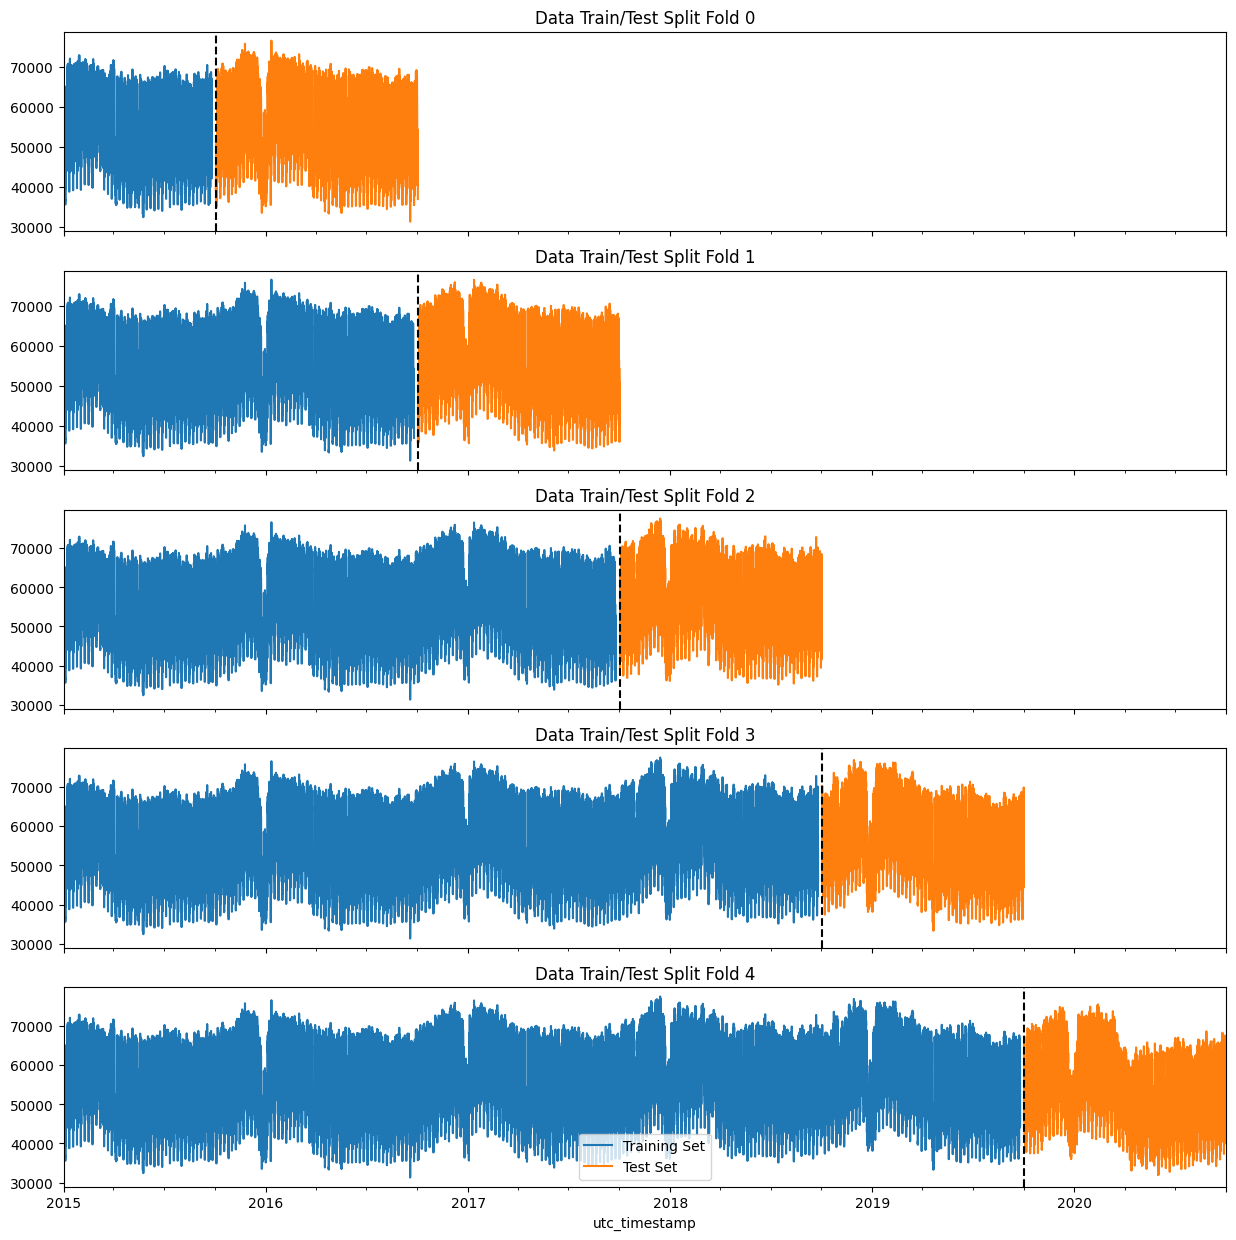

In [8]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(
    n_splits=5, # 5 years of data
    test_size=24*365, # 1 year of test data
    gap=168 # max lag used
)

fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(X):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train[TARGET].plot(ax=axs[fold], label='Training Set', title=f'Data Train/Test Split Fold {fold}')
    test[TARGET].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
    
plt.legend()
plt.show()

# Cross validation

In [9]:
from sklearn.metrics import root_mean_squared_error

tss = TimeSeriesSplit(n_splits=5, test_size=24*365, gap=168)

val_size = 168
test_rmse = []

model_stats = []

for train_idx, test_idx in tss.split(X):
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    X_train = X_train_full[:-val_size]
    y_train = y_train_full[:-val_size]

    X_val = X_train_full[-val_size:]
    y_val = y_train_full[-val_size:]

    reg = xgb.XGBRegressor(booster='gbtree',    
                           n_estimators=5000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.05)

    reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)
    
    model_stats.append( (reg.best_iteration, reg.best_score ) )

    # Test RMSE
    y_pred = reg.predict(X_test)
    score = root_mean_squared_error(y_test, y_pred)
    test_rmse.append(score)

test_rmse = np.array(test_rmse)

# Scores and statistics

In [10]:
print(f'Test RMSE: {test_rmse}')
print(f'Test RMSE mean: {np.mean(test_rmse)}')
print(f'Test RMSE std: {np.std(test_rmse)}\n')

for idx, (iter, score) in enumerate(model_stats):
    print(f'Fold {idx}: best_iters {iter}, best validation RMSE {score}')

Test RMSE: [833.3853406  651.05223454 585.11137431 607.9932311  621.94092416]
Test RMSE mean: 659.8966209444467
Test RMSE std: 89.3353109685479

Fold 0: best_iters 407, best validation RMSE 1416.1198194189267
Fold 1: best_iters 1728, best validation RMSE 775.9317008057674
Fold 2: best_iters 3963, best validation RMSE 401.4434821503136
Fold 3: best_iters 1569, best validation RMSE 684.786790135975
Fold 4: best_iters 3943, best validation RMSE 566.8334391295491


# Model training

In [11]:
from sklearn.model_selection import train_test_split 

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

val_size = 168
gap = 168
X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
X_train, y_train = X_train_full[:-val_size - gap], y_train_full[:-val_size - gap]

model = xgb.XGBRegressor(booster='gbtree',    
                           n_estimators=5000,
                           early_stopping_rounds=100,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.05)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,None


# Predict on test data

In [12]:
y_pred = model.predict(X_test)
print(f'Test RMSE: {root_mean_squared_error(y_test, y_pred)}')

Test RMSE: 617.3582829086474


# Plot random time series true vs. predicted on test set

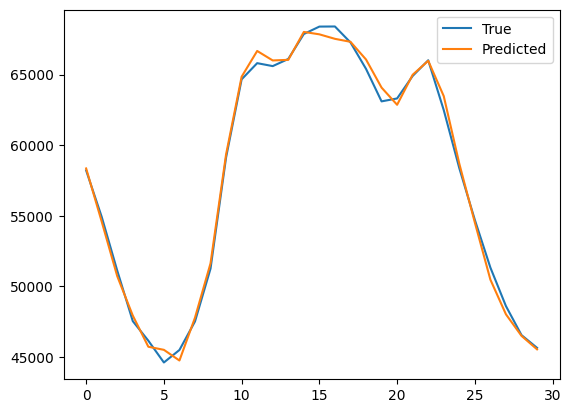

In [13]:
window = 30
idx = np.random.randint(0, len(X_test) - window)

y_pred = model.predict(X_test[idx:idx+window])

plt.plot(range(len(X_test[idx:idx+window])), y_test[idx:idx+window], label="True")
plt.plot(range(len(X_test[idx:idx+window])), y_pred, label="Predicted")
plt.legend()
plt.show()